#### Create cell-type specific pseudobulked count matrices 

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter

In [2]:
plots_dir = "pseudobulk_analysis_plots/"

In [3]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
%%time
adata = sc.read_h5ad("../07_final_RNA_without_scvi.h5ad")
adata

CPU times: user 13.4 s, sys: 1min 21s, total: 1min 34s
Wall time: 2min 5s


AnnData object with n_obs × n_vars = 2305964 × 16115
    obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
    layers: 'counts'

In [5]:
Counter(adata.obs.final_cell_type)

Counter({'Cardiomyocyte': 676654,
         'Fibroblast': 548613,
         'Endothelial': 317124,
         'Pericyte': 281784,
         'Myeloid': 241337,
         'Lymphoid': 69128,
         'vSMC': 59357,
         'Endocardial': 42582,
         'Neuronal': 22613,
         'LEC': 13723,
         'Adipocyte': 12098,
         'Epicardial': 11993,
         'Mast': 8958})

In [6]:
# make sure to use the raw counts
adata.X = adata.layers['counts']
adata.X.sum(axis = 1)

matrix([[  716.],
        [ 1269.],
        [  437.],
        ...,
        [ 5833.],
        [15399.],
        [  498.]])

#### Extract the metadata

In [7]:
adata_metadata = adata.obs[["age", "age_group",  "age_status", 
                            "donor_id", 
                            "sex", 
                            "technology", "study", "tech_plus_study", 
                            "disease_binary", "disease"]].reset_index(drop = True).drop_duplicates().reset_index(drop = True)

In [8]:
output_dir = "raw_pseudobulked_matrices/"
os.makedirs(output_dir, exist_ok = True)

In [9]:
cell_type_key = "final_cell_type"
cell_types_list = adata.obs[cell_type_key].unique()
cell_types_list
donor_key = "donor_id"

### Perform pseudobulking per donor per cell type

- Include number of cells as a covariate

In [10]:
cell_type = "Mast"

In [11]:
cell_type_adata = adata[adata.obs[cell_type_key] == cell_type, :]

In [12]:
counts = Counter(cell_type_adata.obs["donor_id"])

# convert to DataFrame
df_counts = pd.DataFrame.from_dict(counts, orient="index", columns=["count"]).reset_index()
df_counts = df_counts.rename(columns={"index": "donor_id", "count": "cell_count"})

In [13]:
pseudobulked_adata = sc.get.aggregate(cell_type_adata, by = donor_key, func = "sum")

In [14]:
pseudobulked_adata.obs = pseudobulked_adata.obs.merge(adata_metadata, on = donor_key, how = "inner")
pseudobulked_adata.obs_names = pseudobulked_adata.obs[donor_key].astype(str)
pseudobulked_adata.obs = pseudobulked_adata.obs.drop(columns = ["donor_id"])

In [15]:
pseudobulked_count_matrix = pd.DataFrame(pseudobulked_adata.layers['sum'])

In [16]:
total_counts = pseudobulked_count_matrix.sum(axis = 1)

In [17]:
UMI_threshold = 50000
filt_pseudobulked_count_matrix = pseudobulked_count_matrix.loc[total_counts > UMI_threshold, ]

In [18]:
filt_pseudobulked_adata = pseudobulked_adata[total_counts > UMI_threshold, :]
filt_pseudobulked_adata.obs

,age,age_group,age_status,sex,technology,study,tech_plus_study,disease_binary,disease
donor_id,,,,,,,,,
Chaffin 2022:P1290,65.0,old,postnatal,male,3prime-v3,Chaffin 2022,3prime-v3_Chaffin 2022,Y,DCM
Chaffin 2022:P1300,45.0,middle,postnatal,female,3prime-v3,Chaffin 2022,3prime-v3_Chaffin 2022,Y,DCM
Chaffin 2022:P1358,42.0,middle,postnatal,male,3prime-v3,Chaffin 2022,3prime-v3_Chaffin 2022,Y,DCM
Chaffin 2022:P1430,62.0,old,postnatal,male,3prime-v3,Chaffin 2022,3prime-v3_Chaffin 2022,Y,DCM
Chaffin 2022:P1437,63.0,old,postnatal,female,3prime-v3,Chaffin 2022,3prime-v3_Chaffin 2022,Y,DCM
Chaffin 2022:P1462,51.0,middle,postnatal,male,3prime-v3,Chaffin 2022,3prime-v3_Chaffin 2022,Y,HCM
Chaffin 2022:P1472,41.0,middle,postnatal,male,3prime-v3,Chaffin 2022,3prime-v3_Chaffin 2022,Y,DCM
Chaffin 2022:P1539,47.0,middle,postnatal,female,3prime-v3,Chaffin 2022,3prime-v3_Chaffin 2022,N,ND
Chaffin 2022:P1540,72.0,old,postnatal,female,3prime-v3,Chaffin 2022,3prime-v3_Chaffin 2022,N,ND


In [19]:
pseudobulked_count_matrix.shape

(257, 16115)

In [20]:
filt_pseudobulked_count_matrix = pseudobulked_count_matrix.loc[total_counts > UMI_threshold, ]
filt_pseudobulked_count_matrix.shape

(59, 16115)

In [21]:
%%time 

UMI_threshold = 50000

num_donors_per_cell_type = list()

for cell_type in cell_types_list:
    print(cell_type)
    cell_type_adata = adata[adata.obs[cell_type_key] == cell_type, :]

    counts = Counter(cell_type_adata.obs["donor_id"])
    # convert to df
    df_counts = pd.DataFrame.from_dict(counts, orient="index", columns=["count"]).reset_index()
    df_counts = df_counts.rename(columns={"index": "donor_id", "count": "cell_count"})
    
    pseudobulked_adata = sc.get.aggregate(cell_type_adata, by = donor_key, func = "sum")
    pseudobulked_adata.obs = pseudobulked_adata.obs.merge(adata_metadata, on = donor_key, how = "inner")
    pseudobulked_adata.obs_names = pseudobulked_adata.obs[donor_key].astype(str)
    pseudobulked_adata.obs = pseudobulked_adata.obs.drop(columns = ["donor_id"])
    pseudobulked_adata.obs = pseudobulked_adata.obs.merge(df_counts, on = donor_key, how = "inner")

    pseudobulked_count_matrix = pd.DataFrame(pseudobulked_adata.layers['sum'])

    total_counts = pseudobulked_count_matrix.sum(axis = 1)

    # keep only those above the UMI threshold (50K)
    filt_pseudobulked_count_matrix = pseudobulked_count_matrix.loc[total_counts > UMI_threshold, ]
    filt_pseudobulked_adata = pseudobulked_adata[total_counts > UMI_threshold, :]
    
    print(filt_pseudobulked_count_matrix.shape)
    
    num_donors = filt_pseudobulked_count_matrix.shape[0]
    num_donors_per_cell_type.append(num_donors)
    
    filt_pseudobulked_count_matrix.index = filt_pseudobulked_adata.obs_names.astype(str)
    filt_pseudobulked_count_matrix.columns = filt_pseudobulked_adata.var.index
    filt_pseudobulked_count_matrix.to_csv(output_dir + cell_type + "_count_matrix.csv")

    # get corresponding metadata
    metadata = filt_pseudobulked_adata.obs
    #metadata.index = metadata.donor_id.astype(str)
    metadata.to_csv(output_dir + cell_type + "_metadata.csv")

Endothelial
(288, 16115)
Lymphoid
(233, 16115)
Adipocyte
(106, 16115)
Fibroblast
(298, 16115)
vSMC
(261, 16115)
LEC
(125, 16115)
Epicardial
(40, 16115)
Mast
(59, 16115)
Cardiomyocyte
(287, 16115)
Neuronal
(202, 16115)
Pericyte
(294, 16115)
Endocardial
(165, 16115)
Myeloid
(289, 16115)
CPU times: user 53.9 s, sys: 22.4 s, total: 1min 16s
Wall time: 1min 16s


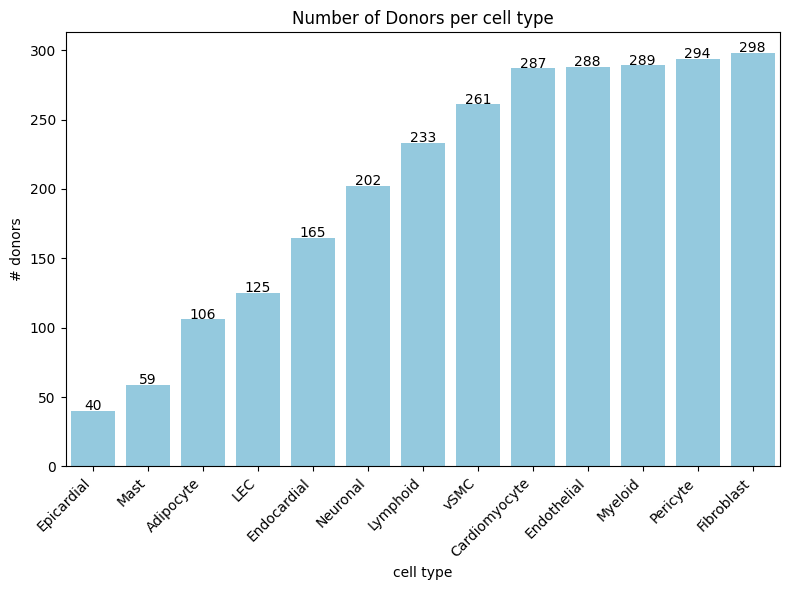

In [22]:
num_donors_per_cell_type_df = pd.DataFrame({
    "cell_type": cell_types_list,
    "num_donors": num_donors_per_cell_type
})

num_donors_per_cell_type_df['cell_type'] = num_donors_per_cell_type_df['cell_type'].astype(str)

# sort in ascending order
num_donors_per_cell_type_df = num_donors_per_cell_type_df.sort_values(
    by="num_donors", ascending=True
)

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=num_donors_per_cell_type_df,
    x='cell_type',
    y='num_donors',
    color="skyblue"
)

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2.,   
        p.get_height() + 0.5,             
        int(p.get_height()),             
        ha='center'
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel('# donors')
plt.xlabel('cell type')
plt.title('Number of Donors per cell type')

plt.tight_layout()
plt.savefig(plots_dir + "num_donors_per_cell_type.pdf")
plt.show()

### Also create a fully pseudobulked sample, without separating by cell type

In [27]:
%%time
pseudobulked_adata = sc.get.aggregate(adata, by = donor_key, func = "sum")

counts = Counter(pseudobulked_adata.obs["donor_id"])
df_counts = pd.DataFrame.from_dict(counts, orient="index", columns=["count"]).reset_index()
df_counts = df_counts.rename(columns={"index": "donor_id", "count": "cell_count"})

pseudobulked_adata.obs = pseudobulked_adata.obs.merge(adata_metadata, on = donor_key, how = "inner")
pseudobulked_adata.obs_names = pseudobulked_adata.obs[donor_key].astype(str)
pseudobulked_adata.obs = pseudobulked_adata.obs.drop(columns = ["donor_id"])
pseudobulked_adata.obs = pseudobulked_adata.obs.merge(df_counts, on = donor_key, how = "inner")

pseudobulked_count_matrix = pd.DataFrame(pseudobulked_adata.layers['sum'])
pseudobulked_count_matrix.index = pseudobulked_adata.obs_names.astype(str)
pseudobulked_count_matrix.columns = pseudobulked_adata.var.index
pseudobulked_count_matrix.to_csv(output_dir  + "pseudobulked_count_matrix.csv")

# get corresponding metadata
metadata = pseudobulked_adata.obs
metadata.to_csv(output_dir + "pseudobulked_metadata.csv")

CPU times: user 14.6 s, sys: 1.54 s, total: 16.1 s
Wall time: 16.1 s
